# Knapsack Solution Visualization

We visualize the predict-then-optimize results to gain an intuitive understanding of how different approaches perform. In this tutorial, we use the knapsack problem as a running example. For each method, the predicted item values, the selected items, and the resource usage are drawn side by side against the true optimum.

## Install (Colab Only)

In [1]:
# install
!pip install pyepo
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.8/149.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.0

Remove a Google Colab import hook that interferes with PyEPO.

In [2]:
import sys
sys.meta_path = [hook for hook in sys.meta_path if not any(keyword in str(hook) for keyword in ["google.colab"])]

## 1 Preparation

### 1.1 Libraries

Let's import useful libraries.

In [3]:
import time
import random
import pyepo
import torch
from matplotlib import pyplot as plt
from matplotlib import colormaps
import numpy as np
from tqdm import tqdm
from torch import nn

Then, we set the random seed for reproducibility.

In [4]:
# fix random seed
random.seed(135)
np.random.seed(135)
torch.manual_seed(135)

### 1.2 Visualization Function

Define a function to visualize predict-then-optimize results on the knapsack.

In [5]:
def visSol(data_loader, optmodel, ind=0, pytorch_model=None, method_name=None):
  # extract solutions by iterating over data loader (pytorch does not provide indexing into it)
  for i, data in enumerate(loader_test):
      if i == ind:
        # load data
        x, c, w, z = data
        # cuda
        if torch.cuda.is_available():
            x, c, w, z = x.cuda(), c.cuda(), w.cuda(), z.cuda()
        # convert to numpy
        c = c.to("cpu").detach().numpy()[0]
        w = w.to("cpu").detach().numpy()[0]
        z = z.to("cpu").detach().numpy()[0]
        # predict
        if pytorch_model is not None:
          cp = pytorch_model(x)
          cp = cp.to("cpu").detach().numpy()
          # solve
          optmodel.setObj(cp[0])
          wp, _ = optmodel.solve()
        else:
          cp = [None]
          wp = w
          method_name = "Groundtruth Optimal Solution"
        # plot
        fig = plotSol(m, c, wp, weights, caps, method_name, cp[0])
        break

In [6]:
# plot function
def plotSol(m, c, w, weights, caps, caption=None, cp=None):
    # colors
    cmap = colormaps["plasma"](np.linspace(0, 1, m))
    # get list
    sol, val, cap1, cap2, cpred = [], [], [], [], []
    for i in range(m):
        sol.append(3)
        val.append(c[i] * w[i])
        cap1.append(weights[0,i] * w[i])
        cap2.append(weights[1,i] * w[i])
        if cp is not None:
          cpred.append(cp[i] * w[i])
    # init fig
    fig = plt.figure(figsize=(8,4))
    plt.gca().invert_yaxis()
    acc = [0, 0, 0, 0]
    # bar plot
    if cp is None:
      for i in range(m):
          bar = [sol[i], val[i], cap1[i], cap2[i]]
          plt.barh(range(4), bar, left=acc, color=cmap[i], height=0.75, edgecolor="w", linewidth=2)
          # not selected
          if not int(w[i]):
              # grey color
              bar = [sol[i], 0, 0, 0]
              plt.barh(range(4), bar, left=acc, color=cmap[i], height=0.75, edgecolor="w", linewidth=2)
              plt.barh(range(4), bar, left=acc, color="lightgrey", height=0.75, edgecolor="w", linewidth=2, alpha=0.9)
          acc = [acc[0]+sol[i], acc[1]+val[i], acc[2]+cap1[i], acc[3]+cap2[i]]
    else:
      acc = [0, 0, 0, 0, 0]
      for i in range(m):
          bar = [sol[i], val[i], cpred[i], cap1[i], cap2[i]]
          plt.barh(range(5), bar, left=acc, color=cmap[i], height=0.75, edgecolor="w", linewidth=2)
          # not selected
          if not int(w[i]):
              # grey color
              bar = [sol[i], 0, 0, 0, 0]
              plt.barh(range(5), bar, left=acc, color=cmap[i], height=0.75, edgecolor="w", linewidth=2)
              plt.barh(range(5), bar, left=acc, color="lightgrey", height=0.75, edgecolor="w", linewidth=2, alpha=0.9)
          acc = [acc[0]+sol[i], acc[1]+val[i], acc[2]+cpred[i], acc[3]+cap1[i], acc[4]+cap2[i]]
    # total value
    tval = sum(val)
    plt.text(tval+0.5, 1.1, tval, fontsize=12)
    # vertical line
    if cp is None:
      plt.axvline(x=caps[0], ymin=0.27, ymax=0.48, color="firebrick", linewidth=1.5)
      plt.text(caps[0]+0.5, 2.1, "Capacity 1", fontsize=12, color="firebrick")
      plt.axvline(x=caps[1], ymin=0.03, ymax=0.24, color="firebrick", linewidth=1.5)
      plt.text(caps[1]+0.5, 3.1, "Capacity 2", fontsize=12, color="firebrick")
    else:
      # total predicted value
      tpredval = sum(cpred)
      plt.text(tpredval+0.5, 2.1, "%.2f"%tpredval, fontsize=12)
      plt.axvline(x=caps[0], ymin=0.23, ymax=0.38, color="firebrick", linewidth=1.5)
      plt.text(caps[0]+0.5, 3.1, "Capacity 1", fontsize=12, color="firebrick")
      plt.axvline(x=caps[1], ymin=0.03, ymax=0.2, color="firebrick", linewidth=1.5)
      plt.text(caps[1]+0.5, 4.1, "Capacity 2", fontsize=12, color="firebrick")
    # labels and ticks
    plt.xticks([])
    bar_labels = ["Items Selection", "Items Predicted Value", "Resource 1", "Resource 2"] if cp is None else ["Items Selection", "Items True Value", "Items Predicted Value", "Resource 1", "Resource 2"]
    plt.yticks(range(len(bar_labels)), bar_labels, fontsize=16)
    plt.minorticks_off()
    plt.tick_params(axis='both', length=0)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)
    plt.title(caption, fontsize=18)
    plt.show()
    return fig

In [7]:
def visLearningCurve(loss_log, regret_log):
    # create figure and subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))

    # draw plot for training loss
    ax1.plot(loss_log, color="c", lw=2)
    ax1.tick_params(axis="both", which="major", labelsize=12)
    ax1.set_xlabel("Iters", fontsize=16)
    ax1.set_ylabel("Loss", fontsize=16)

    # draw plot for regret on test
    ax2.plot(regret_log, color="royalblue", ls="--", alpha=0.7, lw=2)
    ax2.set_xticks(range(0, len(regret_log), 2))
    ax2.tick_params(axis="both", which="major", labelsize=12)
    ax2.set_ylim(0, 0.5)
    ax2.set_xlabel("Epochs", fontsize=16)
    ax2.set_ylabel("Regret", fontsize=16)

    plt.title("Learning Curve on Training Set", fontsize=16)
    plt.show()

### 1.3 Optimization Model, Dataset and Data Loader

#### 1.3.1 Data Generation

We load the synthetic knapsack dataset where the costs $\mathbf{c}$ are unknown and can be predicted from features $\mathbf{x}$. The data generator also provides item weights, which are fixed across all instances since the constraints do not change.

In [8]:
# generate data for 2D knapsack
m = 16 # number of items
n = 100 # number of data
p = 5 # size of feature
deg = 6 # polynomial degree
dim = 2 # dimension of knapsack
noise_width = 0.5 # noise half-width
caps = [20] * dim # capacity
weights, x, c = pyepo.data.knapsack.genData(n+1000, p, m, deg=deg, dim=dim, noise_width=noise_width)

In [9]:
# data split
from sklearn.model_selection import train_test_split
x_train, x_test, c_train, c_test = train_test_split(x, c, test_size=1000, random_state=246)

#### 1.3.2 Optimization Model

We build the knapsack model with the ``pyepo.dsl`` frontend: maximize the total value $\mathbf{c}^\top \mathbf{x}$ subject to the per-resource capacity constraints $\mathbf{W} \mathbf{x} \le \mathbf{caps}$, with binary item-selection variables. The same description compiles to any backend. For more details on ``optModel`` and the DSL, you can read tutorial [01 Optimization Model
](https://github.com/khalil-research/PyEPO/blob/main/notebooks/01%20Optimization%20Model.ipynb) and [documentation](https://khalil-research.github.io/PyEPO/build/html/content/examples/model.html).

In [10]:
from pyepo import EPO, dsl

# knapsack: maximize cᵀx subject to weights·x ≤ caps, x binary
x = dsl.Variable(m, vtype=EPO.BINARY)
c = dsl.Parameter(m)
optmodel = dsl.Problem(dsl.Maximize(c @ x), [weights @ x <= caps]).compile(backend="gurobi")

Restricted license - for non-production use only - expires 2027-11-29


#### 1.3.3 Dataset and Data Loader

PyTorch's ``Dataset`` stores samples $\mathbf{x}$ and their costs $\mathbf{c}$. ``optDataset`` goes further: it uses the solver to find the corresponding optimal solutions $\mathbf{w}^*$ and objective values $\mathbf{z}^*$ for each instance.

More details on ``optDataset`` are [here](https://github.com/khalil-research/PyEPO/blob/main/notebooks/02%20Optimization%20Dataset.ipynb).

In [11]:
# get training data set
dataset_train = pyepo.data.dataset.optDataset(optmodel, x_train, c_train)
# get test data set
dataset_test = pyepo.data.dataset.optDataset(optmodel, x_test, c_test)

100%|██████████| 1000/1000 [00:01<00:00, 692.25it/s]


``DataLoader`` wraps an iterable around the Dataset to enable easy access to the samples.

In [12]:
# get data loader
from torch.utils.data import DataLoader
batch_size = 32
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

### 1.4 PyTorch Linear Regression

In PyTorch, the ``nn.Module`` is a base class for all neural network modules in the library. It provides a convenient way to organize the layers of a model, and to define the forward pass of the model.

We build the simplest PyTorch model: linear regression.

In [13]:
from torch import nn
# build linear model
class LinearRegression(nn.Module):

    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(p, m)

    def forward(self, x):
        out = self.linear(x)
        return out

## 2 Solution Visualization

We visualize solutions to the knapsack problem obtained from different methods, all applied to the same instance. The optimal-solution figure has four rows (selected items, total values, and the two capacity dimensions); the method-comparison figures add a fifth row for the predicted values used to make the decision.

In [14]:
# a index of arbitrary instance to visualize
ind = 0

Define a function to train the model with different methods.

In [15]:
# train model
def trainModel(reg, loss_func, method_name, num_epochs=40, lr=1e-1):
    # set adam optimizer
    optimizer = torch.optim.Adam(reg.parameters(), lr=lr)
    # train mode
    reg.train()
    # log
    loss_log, regret_log = [], [pyepo.metric.regret(reg, optmodel, loader_test)]
    for epoch in range(num_epochs):
        # load data
        for i, data in enumerate(loader_train):
            x, c, w, z = data
            # cuda
            if torch.cuda.is_available():
                x, c, w, z = x.cuda(), c.cuda(), w.cuda(), z.cuda()
            # forward pass
            cp = reg(x)
            if method_name == "spo+":
                loss = loss_func(cp, c, w, z)
            elif method_name in ["ptb", "pfy", "rfwo", "rfyl", "imle", "nce"]:
                loss = loss_func(cp, w)
            elif method_name in ["dbb", "nid"]:
                loss = loss_func(cp, c, z)
            elif method_name in ["2s", "pg", "ltr"]:
                loss = loss_func(cp, c)
            # record loss
            loss_log.append(loss.item())
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        # record regret
        if epoch % 2 == 0:
            regret = pyepo.metric.regret(reg, optmodel, loader_test)
            print("Epoch {:2},  Loss: {:9.4f},  Regret: {:7.4f}%".format(epoch, loss.item(), regret*100))
            regret_log.append(regret)
    # plot
    visLearningCurve(loss_log, regret_log)

### 2.1 Optimal Solution

True optimal solution for current instance.

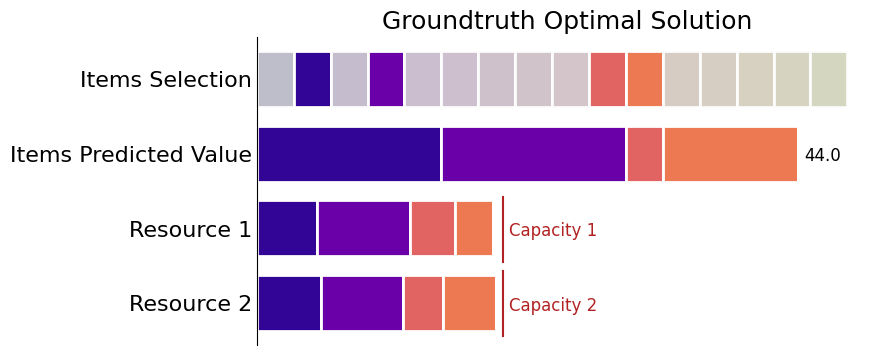

In [16]:
visSol(loader_test, optmodel, ind=ind, pytorch_model=None, method_name=None)

### 2.2 Two-Stage with Linear Regression

Two-stage method: we train a linear regression and then evaluate it.

In [17]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:  134.8594,  Regret: 33.3152%
Epoch  2,  Loss:  426.0872,  Regret: 13.5736%
Epoch  4,  Loss:    6.2839,  Regret: 10.1440%
Epoch  6,  Loss:   11.3960,  Regret:  8.5439%
Epoch  8,  Loss:   23.9876,  Regret:  7.5778%
Epoch 10,  Loss:   33.1396,  Regret:  6.8593%
Epoch 12,  Loss:   14.3398,  Regret:  7.0102%
Epoch 14,  Loss:   82.4736,  Regret:  7.5989%
Epoch 16,  Loss:    7.7356,  Regret:  8.0518%
Epoch 18,  Loss:    7.5153,  Regret:  8.2088%
Epoch 20,  Loss:    8.3157,  Regret:  8.6617%
Epoch 22,  Loss:   74.6368,  Regret:  8.9183%
Epoch 24,  Loss:    8.6579,  Regret:  9.5130%
Epoch 26,  Loss:    8.4490,  Regret:  9.7002%
Epoch 28,  Loss:    9.0721,  Regret:  9.8391%
Epoch 30,  Loss:    8.7236,  Regret: 10.5516%
Epoch 32,  Loss:   12.2261,  Regret: 10.4338%
Epoch 34,  Loss:   11.6751,  Regret: 10.3855%
Epoch 36,  Loss:   25.5984,  Regret: 10.2919%
Epoch 38,  Loss:   18.8297,  Regret: 10.5455%


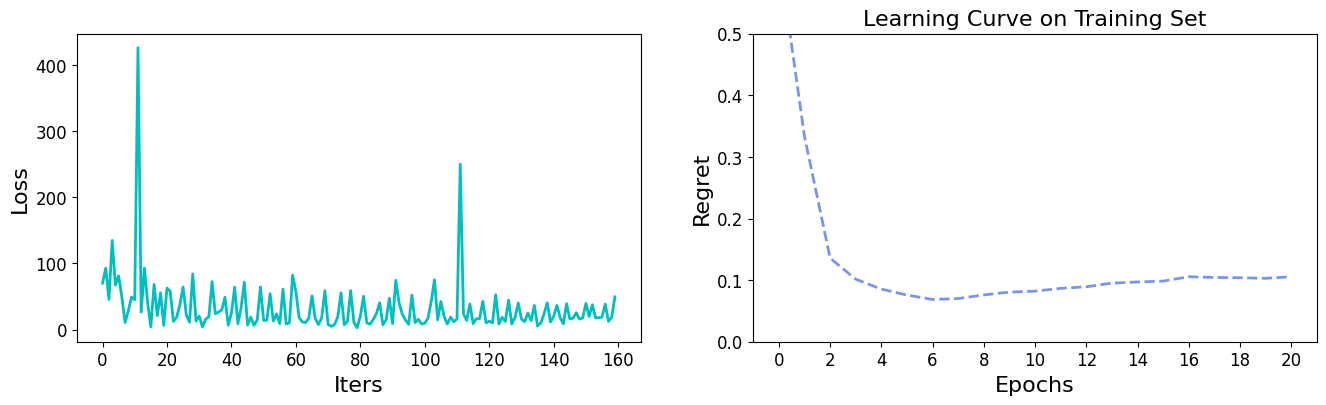

In [18]:
# init MSE loss
mse = nn.MSELoss()
# train
trainModel(reg, loss_func=mse, method_name="2s")

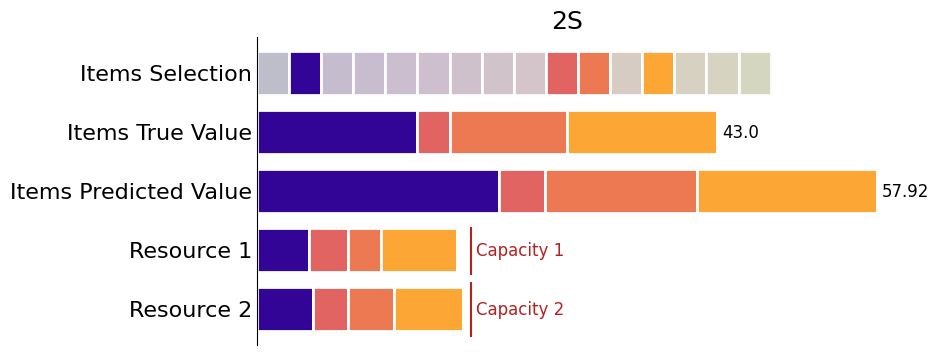

In [19]:
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="2S")

### 2.3 Surrogate Loss

#### 2.3.1 SPO+

Smart Predict-then-Optimize+ Loss

In [20]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:   68.8291,  Regret: 14.1654%
Epoch  2,  Loss:    7.2017,  Regret:  7.5054%
Epoch  4,  Loss:   23.9046,  Regret:  7.1582%
Epoch  6,  Loss:    7.5329,  Regret:  6.7295%
Epoch  8,  Loss:    5.4387,  Regret:  6.5755%
Epoch 10,  Loss:    9.4097,  Regret:  6.4457%
Epoch 12,  Loss:   13.0226,  Regret:  5.9898%
Epoch 14,  Loss:    6.9788,  Regret:  6.0683%
Epoch 16,  Loss:    3.1033,  Regret:  6.0230%
Epoch 18,  Loss:   10.1167,  Regret:  6.0230%
Epoch 20,  Loss:    2.1611,  Regret:  6.0109%
Epoch 22,  Loss:   11.9983,  Regret:  6.1740%
Epoch 24,  Loss:    2.7352,  Regret:  6.0804%
Epoch 26,  Loss:   12.0269,  Regret:  6.1860%
Epoch 28,  Loss:    8.8394,  Regret:  6.0109%
Epoch 30,  Loss:    1.4280,  Regret:  5.9898%
Epoch 32,  Loss:    5.8524,  Regret:  6.0230%
Epoch 34,  Loss:    8.0610,  Regret:  6.3883%
Epoch 36,  Loss:   18.5781,  Regret:  6.5725%
Epoch 38,  Loss:    2.7615,  Regret:  6.2675%


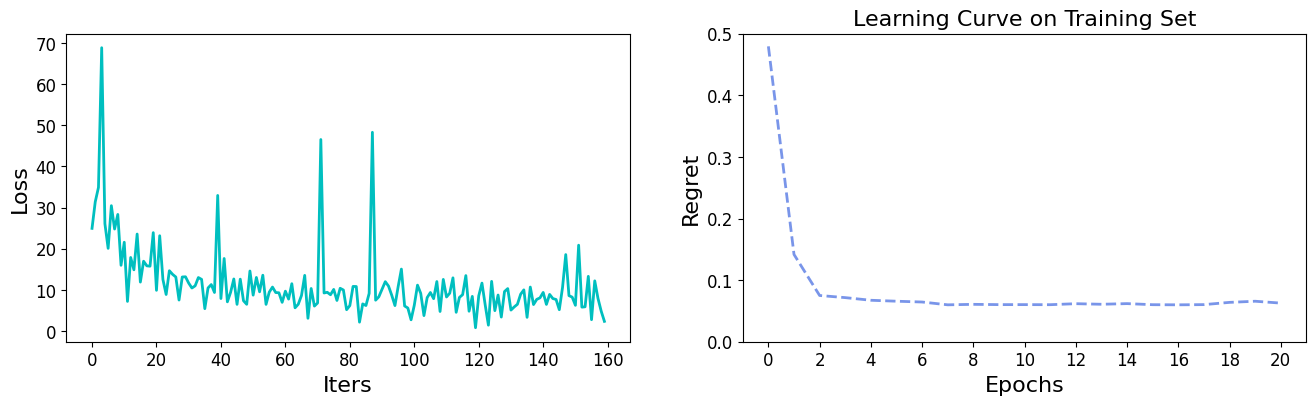

In [21]:
# init SPO+ loss
spop = pyepo.func.SPOPlus(optmodel, processes=1)
# train
trainModel(reg, loss_func=spop, method_name="spo+")

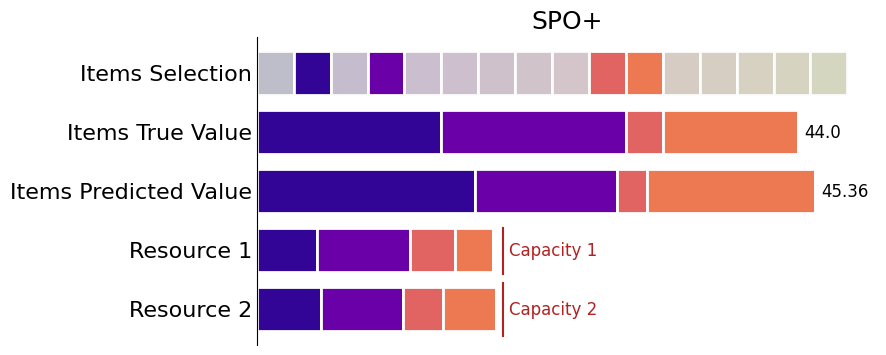

In [22]:
# compare solutions
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="SPO+")

#### 2.3.2 PG

Perturbation Gradient Loss

In [23]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:   -4.8759,  Regret: 49.3434%
Epoch  2,  Loss:   -5.3669,  Regret: 44.6155%
Epoch  4,  Loss:  -12.9970,  Regret: 39.9300%
Epoch  6,  Loss:  -13.4847,  Regret: 36.2346%
Epoch  8,  Loss:   -7.2888,  Regret: 32.6420%
Epoch 10,  Loss:  -17.0586,  Regret: 29.5112%
Epoch 12,  Loss:  -11.6949,  Regret: 26.9239%
Epoch 14,  Loss:  -20.5075,  Regret: 24.8498%
Epoch 16,  Loss:  -25.3725,  Regret: 23.0414%
Epoch 18,  Loss:  -40.7956,  Regret: 21.8760%
Epoch 20,  Loss:  -14.6756,  Regret: 21.1243%
Epoch 22,  Loss:  -20.6964,  Regret: 20.4994%
Epoch 24,  Loss:  -14.9790,  Regret: 20.0857%
Epoch 26,  Loss:  -11.2500,  Regret: 19.6480%
Epoch 28,  Loss:  -14.6419,  Regret: 19.2887%
Epoch 30,  Loss:  -37.2829,  Regret: 19.2857%
Epoch 32,  Loss:  -22.8383,  Regret: 19.2555%
Epoch 34,  Loss:  -15.5000,  Regret: 19.0532%
Epoch 36,  Loss:  -40.2343,  Regret: 19.0895%
Epoch 38,  Loss:  -32.8074,  Regret: 18.9717%


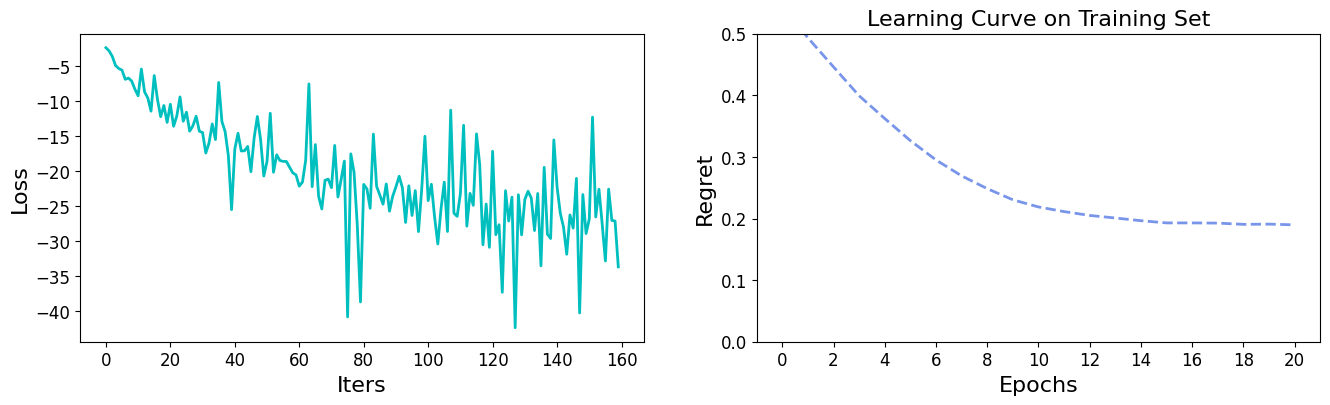

In [24]:
# init SPO+ loss
pg = pyepo.func.PG(optmodel, sigma=1.0, two_sides=False, processes=1)
# train
trainModel(reg, loss_func=pg, method_name="pg")

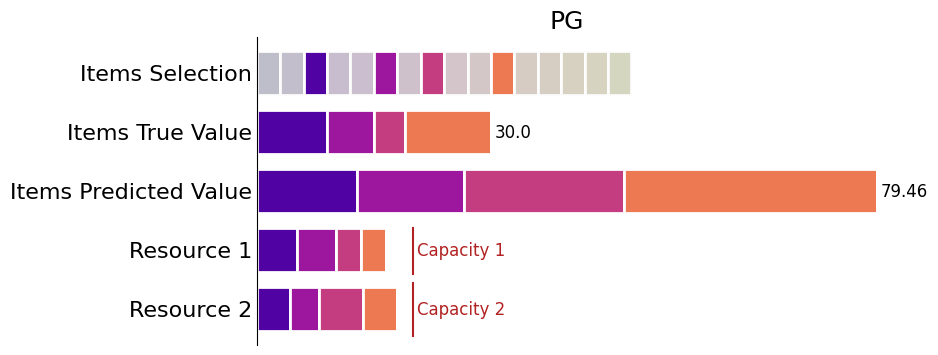

In [25]:
# compare solutions
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="PG")

### 2.4 Perturbed Methods

#### 2.4.1  PFYL

Fenchel-Young Loss with Perturbation

In [26]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:    1.8045,  Regret: 14.7692%
Epoch  2,  Loss:    0.5904,  Regret:  9.8753%
Epoch  4,  Loss:    1.7514,  Regret:  9.5311%
Epoch  6,  Loss:    1.0892,  Regret:  8.3447%
Epoch  8,  Loss:    0.7496,  Regret:  9.3953%
Epoch 10,  Loss:    1.1002,  Regret:  9.1689%
Epoch 12,  Loss:    0.8485,  Regret:  7.0585%
Epoch 14,  Loss:    0.3621,  Regret:  7.8918%
Epoch 16,  Loss:    0.9669,  Regret:  8.5349%
Epoch 18,  Loss:    0.9677,  Regret:  9.3319%
Epoch 20,  Loss:    0.5709,  Regret:  9.5130%
Epoch 22,  Loss:    0.5072,  Regret:  8.3839%
Epoch 24,  Loss:    0.8498,  Regret:  7.7408%
Epoch 26,  Loss:    0.9898,  Regret:  8.3688%
Epoch 28,  Loss:    0.4861,  Regret:  8.9575%
Epoch 30,  Loss:    0.9592,  Regret:  7.9371%
Epoch 32,  Loss:    0.8227,  Regret:  7.1370%
Epoch 34,  Loss:    0.4407,  Regret:  7.4903%
Epoch 36,  Loss:    1.1674,  Regret:  8.2692%
Epoch 38,  Loss:    0.8535,  Regret:  8.0277%


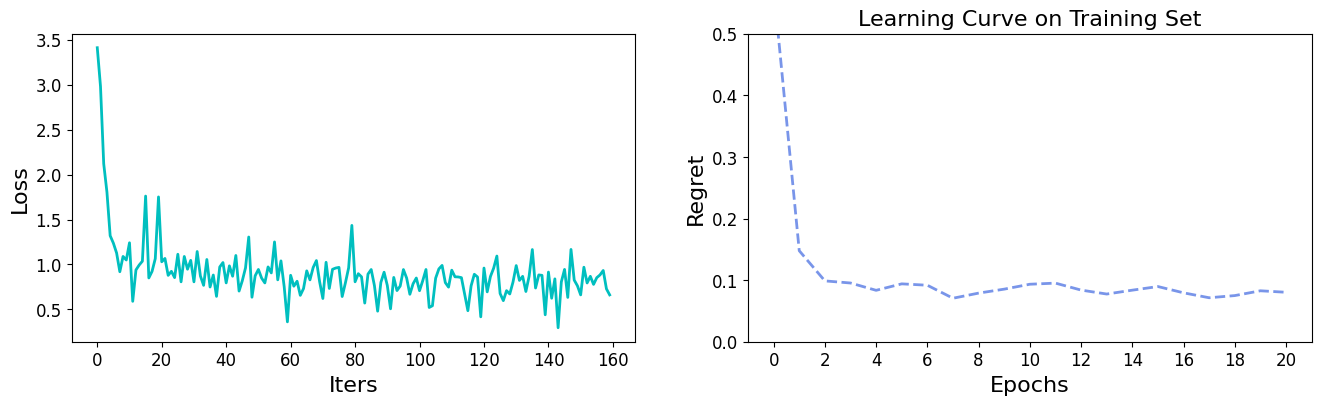

In [27]:
# init pfy loss
pfy = pyepo.func.PFY(optmodel, n_samples=10, sigma=0.5, processes=1)
# PFYL multiplicative variant for sign-sensitive oracles
# pfy = pyepo.func.PFYMul(optmodel, n_samples=10, sigma=0.5, processes=1)
# train
trainModel(reg, loss_func=pfy, method_name="pfy")

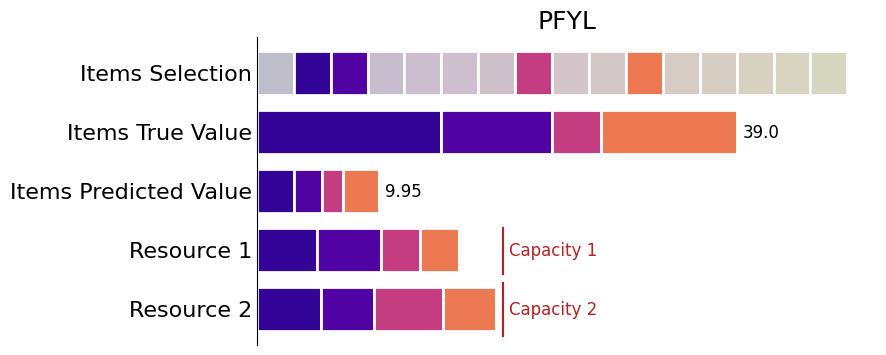

In [28]:
# compare solutions
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="PFYL")

#### 2.4.2 DPO

Differentiable Perturbed Optimizer with L1 Loss

In [29]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:    0.2703,  Regret: 29.3693%
Epoch  2,  Loss:    0.2094,  Regret: 20.2276%
Epoch  4,  Loss:    0.2062,  Regret: 16.9882%
Epoch  6,  Loss:    0.1781,  Regret: 15.8621%
Epoch  8,  Loss:    0.1750,  Regret: 14.8235%
Epoch 10,  Loss:    0.1234,  Regret: 14.9835%
Epoch 12,  Loss:    0.1344,  Regret: 13.5133%
Epoch 14,  Loss:    0.1063,  Regret: 12.9759%
Epoch 16,  Loss:    0.1719,  Regret: 12.3056%
Epoch 18,  Loss:    0.1187,  Regret: 12.0822%
Epoch 20,  Loss:    0.1547,  Regret: 12.1275%
Epoch 22,  Loss:    0.1641,  Regret: 12.2030%
Epoch 24,  Loss:    0.2016,  Regret: 13.4408%
Epoch 26,  Loss:    0.0812,  Regret: 12.9246%
Epoch 28,  Loss:    0.1750,  Regret: 12.8189%
Epoch 30,  Loss:    0.1750,  Regret: 12.8159%
Epoch 32,  Loss:    0.1813,  Regret: 12.4445%
Epoch 34,  Loss:    0.0844,  Regret: 11.3999%
Epoch 36,  Loss:    0.1062,  Regret: 11.8860%
Epoch 38,  Loss:    0.1859,  Regret: 12.2121%


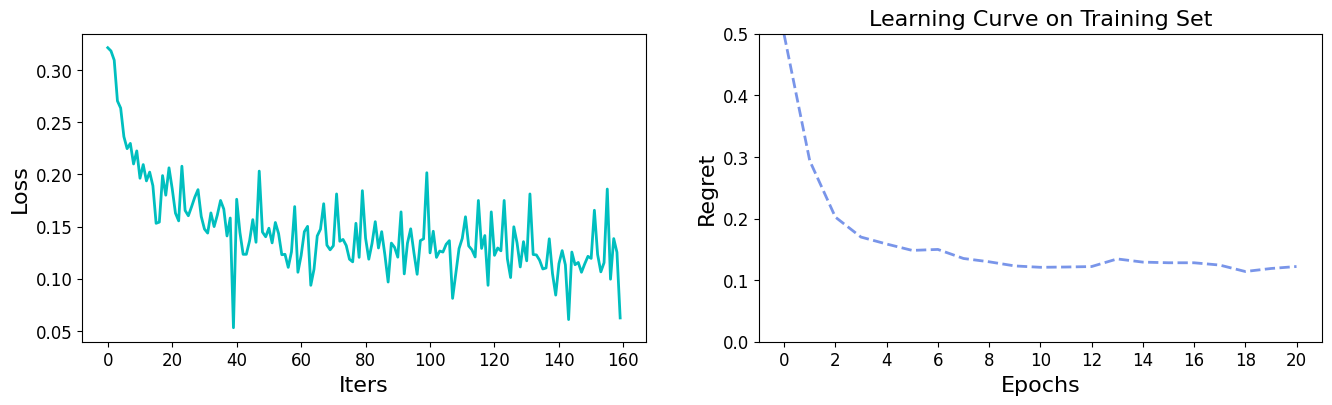

In [30]:
# init ptb solver
ptb = pyepo.func.DPO(optmodel, n_samples=10, sigma=0.5, processes=1)
# DPO multiplicative variant for sign-sensitive oracles
# ptb = pyepo.func.DPOMul(optmodel, n_samples=10, sigma=0.5, processes=1)
# set loss
l1 = nn.L1Loss()

# loss function
def ptbl1(cp, w):
    # perturbed optimizer
    we = ptb(cp)
    # loss
    loss = l1(we, w)
    return loss

# train
trainModel(reg, loss_func=ptbl1, method_name="ptb")

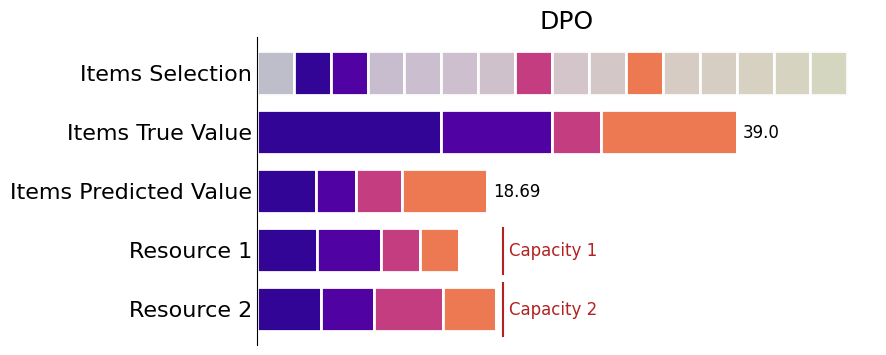

In [31]:
# compare solutions
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="DPO")

#### 2.4.3 I-MLE

Implicit Maximum Likelihood Estimator

In [32]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:    0.1813,  Regret: 42.0312%
Epoch  2,  Loss:    0.2094,  Regret: 25.1215%
Epoch  4,  Loss:    0.1859,  Regret: 20.9733%
Epoch  6,  Loss:    0.1937,  Regret: 20.2095%
Epoch  8,  Loss:    0.1187,  Regret: 18.3921%
Epoch 10,  Loss:    0.1375,  Regret: 16.1006%
Epoch 12,  Loss:    0.1531,  Regret: 15.6477%
Epoch 14,  Loss:    0.1813,  Regret: 16.6108%
Epoch 16,  Loss:    0.2031,  Regret: 16.8554%
Epoch 18,  Loss:    0.1359,  Regret: 15.9527%
Epoch 20,  Loss:    0.1312,  Regret: 14.6424%
Epoch 22,  Loss:    0.1359,  Regret: 14.7903%
Epoch 24,  Loss:    0.1078,  Regret: 14.6816%
Epoch 26,  Loss:    0.1156,  Regret: 14.1593%
Epoch 28,  Loss:    0.1531,  Regret: 13.8544%
Epoch 30,  Loss:    0.1094,  Regret: 13.9571%
Epoch 32,  Loss:    0.1094,  Regret: 14.0688%
Epoch 34,  Loss:    0.1750,  Regret: 14.2409%
Epoch 36,  Loss:    0.1656,  Regret: 14.5941%
Epoch 38,  Loss:    0.1344,  Regret: 13.9752%


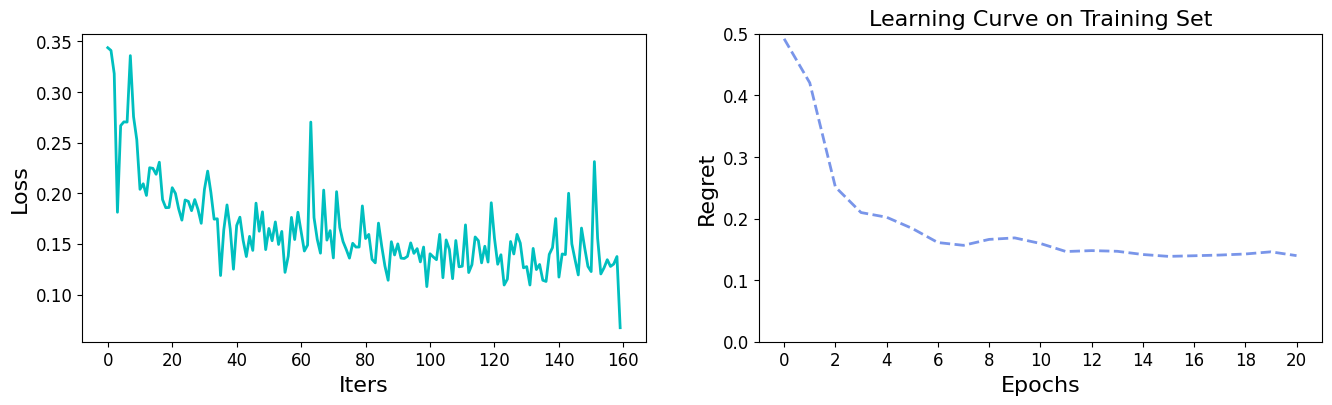

In [33]:
# init imle solver
imle = pyepo.func.IMLE(optmodel, n_samples=10, sigma=1.0, lambd=10, processes=2)
# set loss
l1 = nn.L1Loss()

# loss function
def imlel1(cp, w):
    # perturbed optimizer
    we = imle(cp)
    # loss
    loss = l1(we, w)
    return loss

# train
trainModel(reg, loss_func=imlel1, method_name="imle")

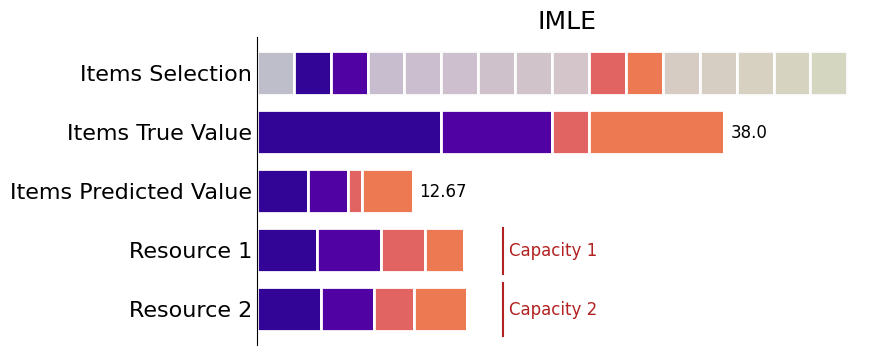

In [34]:
# compare solutions
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="IMLE")

### 2.5 Regularized Methods

[Dalle, G., Baty, L., Bouvier, L., & Parmentier, A. (2022). Learning with combinatorial optimization layers: a probabilistic approach. arXiv:2207.13513.](https://arxiv.org/abs/2207.13513)

Regularized methods add a convex regularizer to make the optimizer smoother. Here we visualize the L2 regularized Frank-Wolfe optimizer and its Fenchel-Young loss variant.

#### 2.5.1 L2 Regularized Frank-Wolfe Optimizer

The L2 regularized Frank-Wolfe optimizer returns a smooth solution within the convex hull of feasible decisions. Since ``RFWO`` gives a solution rather than a loss, we train it using solution-level MSE loss, following the imitation-learning approach in the paper.


In [35]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:    0.1656,  Regret: 25.6680%
Epoch  2,  Loss:    0.1990,  Regret: 20.0254%
Epoch  4,  Loss:    0.1523,  Regret: 15.8228%
Epoch  6,  Loss:    0.0806,  Regret: 13.2416%
Epoch  8,  Loss:    0.0984,  Regret: 11.5509%
Epoch 10,  Loss:    0.1255,  Regret: 10.7237%
Epoch 12,  Loss:    0.0836,  Regret: 11.3154%
Epoch 14,  Loss:    0.0623,  Regret: 10.9018%
Epoch 16,  Loss:    0.0935,  Regret: 10.7508%
Epoch 18,  Loss:    0.0377,  Regret:  9.8693%
Epoch 20,  Loss:    0.1313,  Regret:  9.8632%
Epoch 22,  Loss:    0.0910,  Regret: 10.5184%
Epoch 24,  Loss:    0.1111,  Regret:  9.9176%
Epoch 26,  Loss:    0.1012,  Regret: 10.0353%
Epoch 28,  Loss:    0.1078,  Regret: 10.0987%
Epoch 30,  Loss:    0.1137,  Regret:  9.9508%
Epoch 32,  Loss:    0.0905,  Regret: 10.0655%
Epoch 34,  Loss:    0.0063,  Regret: 10.4369%
Epoch 36,  Loss:    0.1026,  Regret: 10.4399%
Epoch 38,  Loss:    0.0681,  Regret: 10.0202%


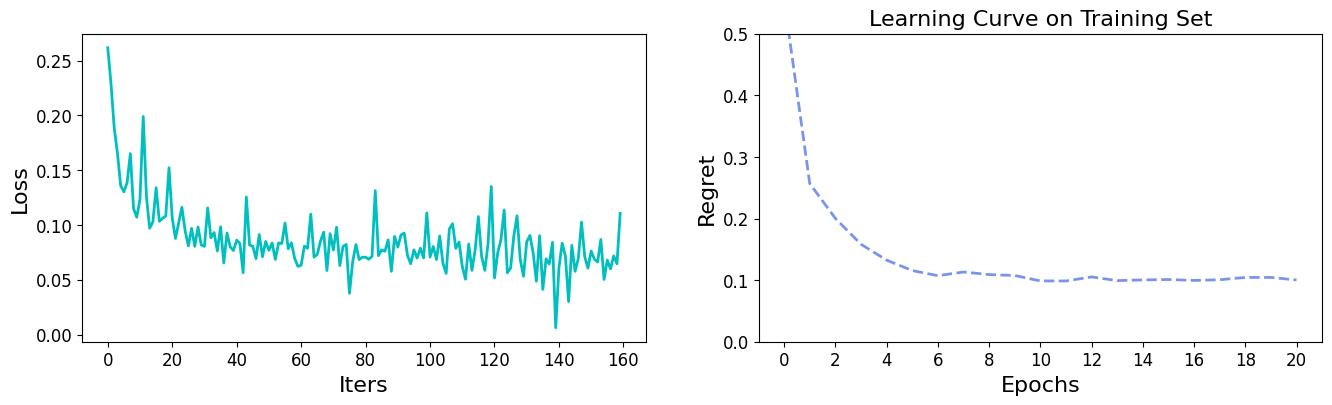

In [36]:
# init L2 regularized Frank-Wolfe optimizer
rfwo = pyepo.func.RFWO(optmodel, lambd=1.0, max_iter=20, tol=1e-6, processes=1)
# set loss
mseloss = nn.MSELoss()

# loss function
def rfwomse(cp, w):
    # regularized optimizer
    wr = rfwo(cp)
    # solution-level MSE loss
    loss = mseloss(wr, w)
    return loss

# train
trainModel(reg, loss_func=rfwomse, method_name="rfwo")

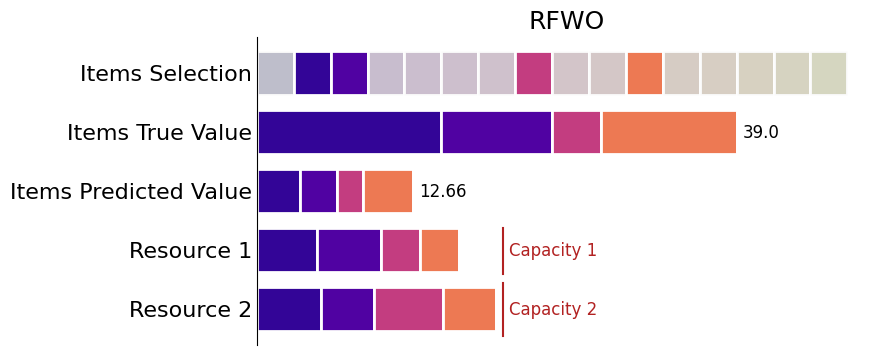

In [37]:
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="RFWO")

#### 2.5.2 L2 Regularized Frank-Wolfe with Fenchel-Young Loss

Regularized Frank-Wolfe with Fenchel-Young loss computes the L2 regularized Fenchel-Young objective directly from predicted costs and true optimal solutions.

In [38]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:    1.2187,  Regret: 16.2093%
Epoch  2,  Loss:    0.5399,  Regret: 10.3040%
Epoch  4,  Loss:    0.8912,  Regret:  9.6006%
Epoch  6,  Loss:    0.6980,  Regret:  8.7583%
Epoch  8,  Loss:    0.3478,  Regret:  7.7016%
Epoch 10,  Loss:    0.6705,  Regret:  6.8865%
Epoch 12,  Loss:    0.7881,  Regret:  7.8435%
Epoch 14,  Loss:    0.3333,  Regret:  8.8096%
Epoch 16,  Loss:    0.6697,  Regret:  7.6714%
Epoch 18,  Loss:    0.4501,  Regret:  9.0541%
Epoch 20,  Loss:    0.8208,  Regret:  8.9062%
Epoch 22,  Loss:    0.6374,  Regret:  8.3205%
Epoch 24,  Loss:    0.6336,  Regret:  9.1568%
Epoch 26,  Loss:    0.8931,  Regret:  9.0873%
Epoch 28,  Loss:    0.7881,  Regret:  8.4624%
Epoch 30,  Loss:    0.8496,  Regret:  8.5228%
Epoch 32,  Loss:    0.8180,  Regret:  8.6224%
Epoch 34,  Loss:    0.8808,  Regret:  9.1356%
Epoch 36,  Loss:    0.5899,  Regret:  8.3779%
Epoch 38,  Loss:    0.3340,  Regret:  8.3960%


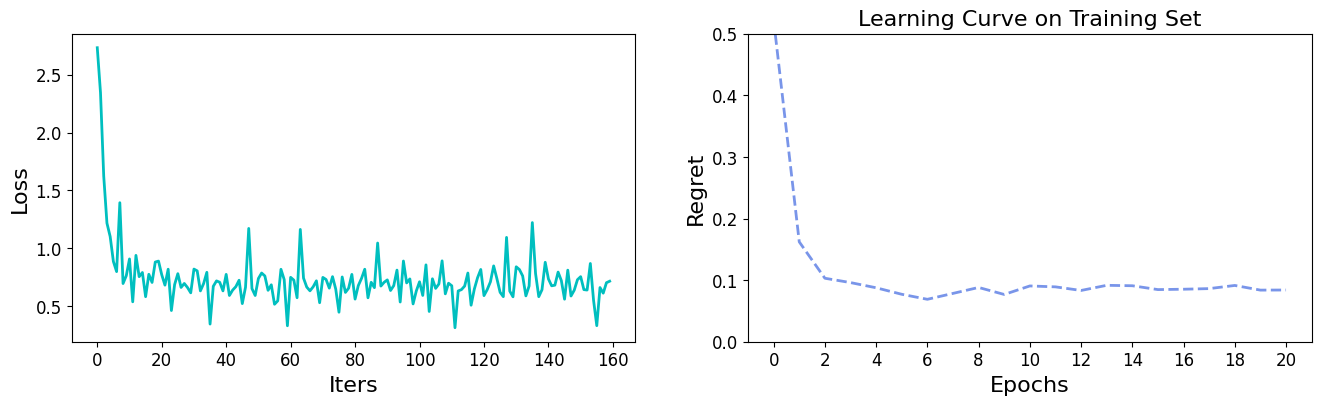

In [39]:
# init L2 regularized Frank-Wolfe with Fenchel-Young loss
rfyl = pyepo.func.RFY(optmodel, lambd=1.0, max_iter=20, tol=1e-6, processes=1)
# train
trainModel(reg, loss_func=rfyl, method_name="rfyl")

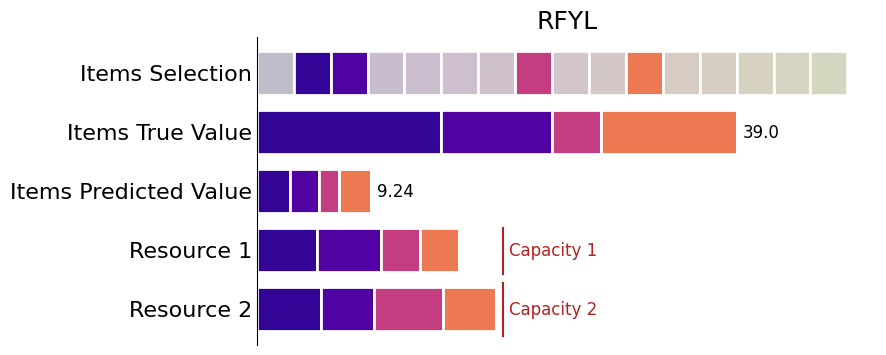

In [40]:
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="RFYL")

### 2.6 Black-Box Methods

#### 2.6.1 DBB

Differentiable Black-Box with Regret Loss

In [41]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:   11.7500,  Regret: 50.5993%
Epoch  2,  Loss:   16.2500,  Regret: 43.7581%
Epoch  4,  Loss:   20.7500,  Regret: 34.8549%
Epoch  6,  Loss:    5.2500,  Regret: 29.8916%
Epoch  8,  Loss:    5.0000,  Regret: 25.9065%
Epoch 10,  Loss:    7.0000,  Regret: 23.1591%
Epoch 12,  Loss:    7.5000,  Regret: 21.5047%
Epoch 14,  Loss:    2.0000,  Regret: 20.2337%
Epoch 16,  Loss:    0.7500,  Regret: 18.9264%
Epoch 18,  Loss:    3.7500,  Regret: 18.4645%
Epoch 20,  Loss:    4.0000,  Regret: 17.9483%
Epoch 22,  Loss:    5.0000,  Regret: 17.6645%
Epoch 24,  Loss:    5.2500,  Regret: 17.4833%
Epoch 26,  Loss:    1.5000,  Regret: 17.1935%
Epoch 28,  Loss:    3.0000,  Regret: 17.0184%
Epoch 30,  Loss:    3.5000,  Regret: 17.2297%
Epoch 32,  Loss:    5.5000,  Regret: 17.1361%
Epoch 34,  Loss:    7.2500,  Regret: 16.9339%
Epoch 36,  Loss:    0.7500,  Regret: 17.1180%
Epoch 38,  Loss:    1.2500,  Regret: 17.0033%


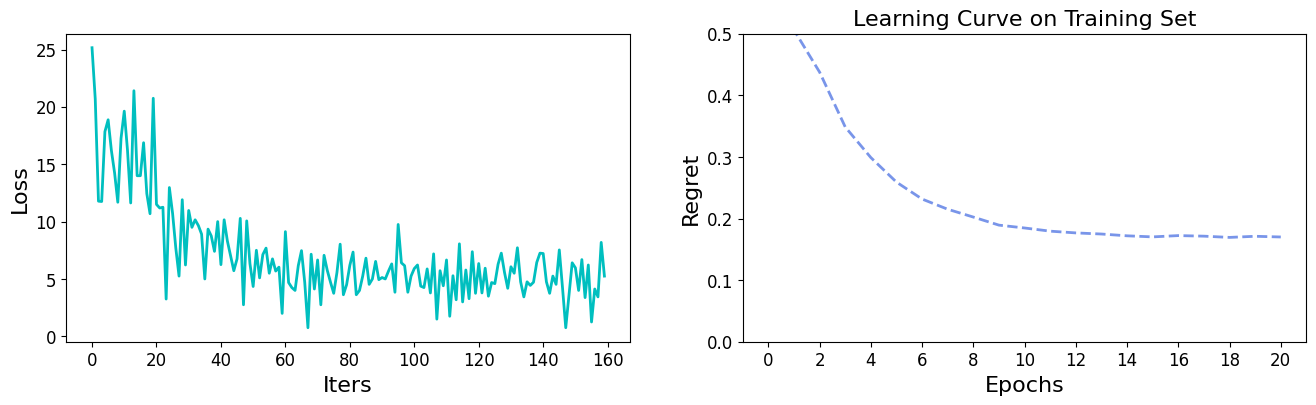

In [42]:
# init dbb solver
dbb = pyepo.func.DBB(optmodel, lambd=20, processes=1)
# set loss
l1 = nn.L1Loss()

# loss function
def dbbl1(cp, c, z):
    # black-box optimizer
    wp = dbb(cp)
    # objective value
    zp = (wp * c).sum(1).view(-1, 1)
    # loss
    loss = l1(zp, z)
    return loss

trainModel(reg, loss_func=dbbl1, method_name="dbb")

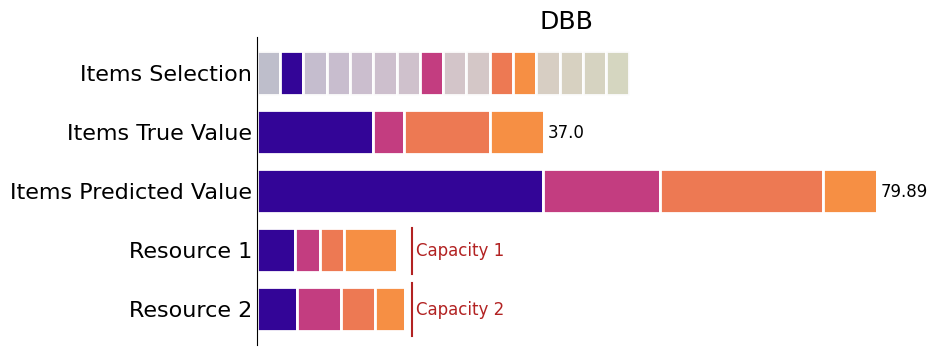

In [43]:
# compare solutions
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="DBB")

#### 2.6.2 NID

Negative Identity Backpropagation with Regret

In [44]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:   12.5000,  Regret: 31.7815%
Epoch  2,  Loss:    6.5000,  Regret: 18.5460%
Epoch  4,  Loss:    4.7500,  Regret: 16.5051%
Epoch  6,  Loss:    4.5000,  Regret: 15.4273%
Epoch  8,  Loss:    3.2500,  Regret: 14.2741%
Epoch 10,  Loss:    2.5000,  Regret: 13.1268%
Epoch 12,  Loss:    6.2500,  Regret: 12.8189%
Epoch 14,  Loss:    1.5000,  Regret: 12.2664%
Epoch 16,  Loss:    1.2500,  Regret: 12.0702%
Epoch 18,  Loss:    7.0000,  Regret: 11.8377%
Epoch 20,  Loss:    4.0000,  Regret: 11.5056%
Epoch 22,  Loss:    1.7500,  Regret: 11.4664%
Epoch 24,  Loss:    0.5000,  Regret: 11.3788%
Epoch 26,  Loss:    0.5000,  Regret: 11.0044%
Epoch 28,  Loss:    3.2500,  Regret: 10.9531%
Epoch 30,  Loss:    1.7500,  Regret: 10.8444%
Epoch 32,  Loss:    4.5000,  Regret: 10.8686%
Epoch 34,  Loss:    3.2500,  Regret: 10.8595%
Epoch 36,  Loss:    0.5000,  Regret: 10.9893%
Epoch 38,  Loss:    3.7500,  Regret: 11.0105%


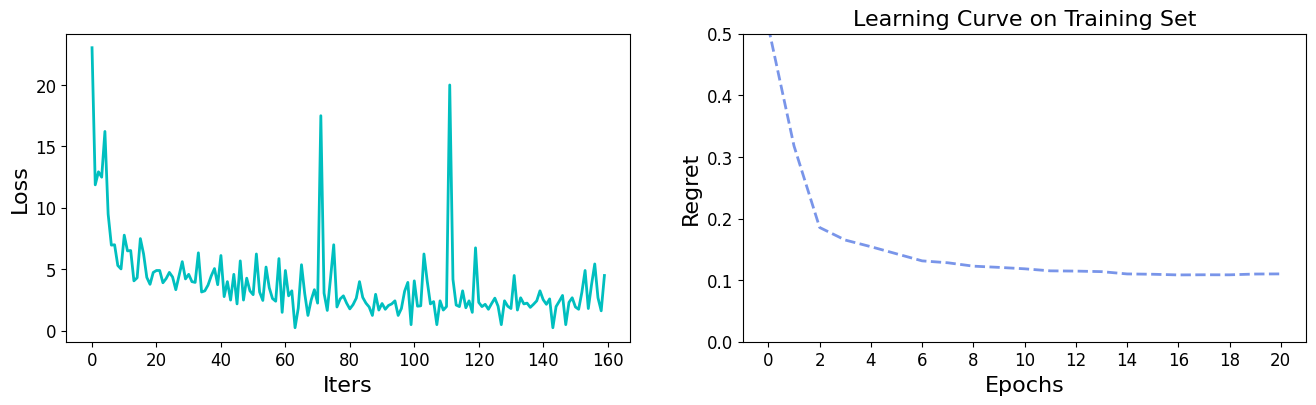

In [45]:
# init dbb solver
nid = pyepo.func.NID(optmodel, processes=2)
# set loss
l1 = nn.L1Loss()

# loss function
def nidl1(cp, c, z):
    # black-box optimizer
    wp = nid(cp)
    # objective value
    zp = (wp * c).sum(1).view(-1, 1)
    # loss
    loss = l1(zp, z)
    return loss

trainModel(reg, loss_func=nidl1, method_name="nid")

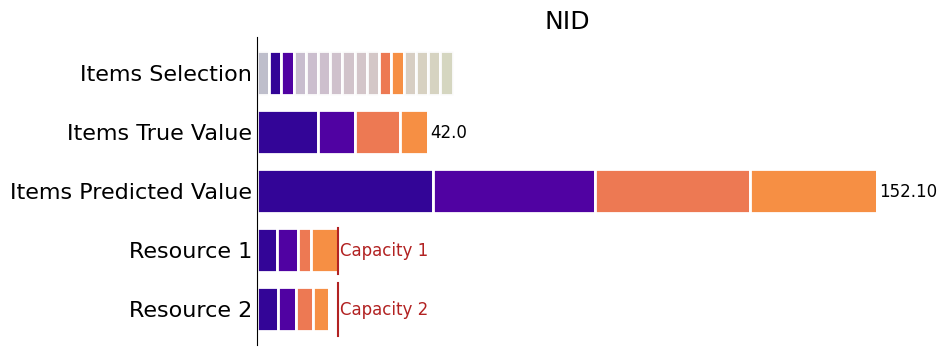

In [46]:
# compare solutions
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="NID")

### 2.7 Contrastive & Ranking Method

#### 2.7.1 NCE

Noise Contrastive Estimation

In [47]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:   -3.3710,  Regret: 18.8902%
Epoch  2,  Loss:   -8.5984,  Regret: 11.4271%
Epoch  4,  Loss:  -10.5204,  Regret:  9.5191%
Epoch  6,  Loss:  -18.3814,  Regret:  8.5318%
Epoch  8,  Loss:  -14.7324,  Regret:  7.8435%
Epoch 10,  Loss:  -31.9972,  Regret:  7.6473%
Epoch 12,  Loss:  -31.1841,  Regret:  7.8978%
Epoch 14,  Loss:  -36.7417,  Regret:  7.7771%
Epoch 16,  Loss:  -48.5296,  Regret:  7.8344%
Epoch 18,  Loss:  -40.3614,  Regret:  7.4721%
Epoch 20,  Loss:  -61.3363,  Regret:  7.3363%
Epoch 22,  Loss:  -35.7076,  Regret:  6.9982%
Epoch 24,  Loss:  -43.6109,  Regret:  6.8563%
Epoch 26,  Loss:  -40.9197,  Regret:  6.8804%
Epoch 28,  Loss:  -83.3638,  Regret:  6.9076%
Epoch 30,  Loss:  -83.3179,  Regret:  6.8985%
Epoch 32,  Loss:  -91.3836,  Regret:  6.9015%
Epoch 34,  Loss:  -79.9577,  Regret:  6.9408%
Epoch 36,  Loss: -101.3682,  Regret:  6.8985%
Epoch 38,  Loss:  -88.0884,  Regret:  6.8925%


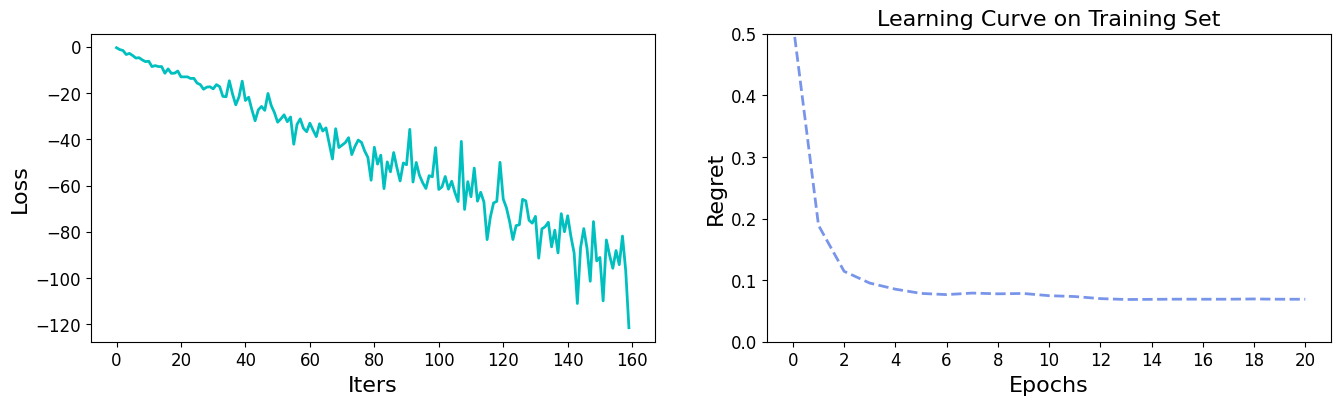

In [48]:
# init nce loss
nce = pyepo.func.NCE(optmodel, processes=1, solve_ratio=0.10, dataset=dataset_train)
# train
trainModel(reg, loss_func=nce, method_name="nce")

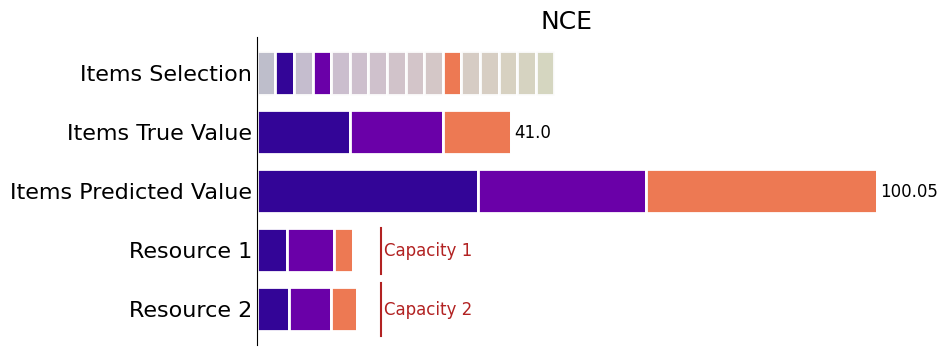

In [49]:
# compare solutions
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="NCE")

#### 2.7.2 LTR

Listwise Learning to Rank

In [50]:
# init model
reg = LinearRegression()
# cuda
if torch.cuda.is_available():
    reg = reg.cuda()

Epoch  0,  Loss:    4.1121,  Regret: 17.5045%
Epoch  2,  Loss:    3.5066,  Regret: 13.6370%
Epoch  4,  Loss:    3.0310,  Regret: 15.1194%
Epoch  6,  Loss:    3.1160,  Regret: 14.8386%
Epoch  8,  Loss:    2.8902,  Regret: 15.7111%
Epoch 10,  Loss:    3.0492,  Regret: 14.0899%
Epoch 12,  Loss:    3.9554,  Regret: 14.3314%
Epoch 14,  Loss:    2.9967,  Regret: 12.9940%
Epoch 16,  Loss:    4.3052,  Regret: 11.7230%
Epoch 18,  Loss:    2.8621,  Regret: 13.1691%
Epoch 20,  Loss:    3.2970,  Regret: 12.9849%
Epoch 22,  Loss:    3.3678,  Regret: 13.3865%
Epoch 24,  Loss:    2.8749,  Regret: 12.3932%
Epoch 26,  Loss:    3.8965,  Regret: 13.1691%
Epoch 28,  Loss:    3.1224,  Regret: 14.0688%
Epoch 30,  Loss:    1.8553,  Regret: 11.7683%
Epoch 32,  Loss:    3.4244,  Regret: 11.2882%
Epoch 34,  Loss:    4.2980,  Regret: 11.5056%
Epoch 36,  Loss:    4.3890,  Regret: 13.8574%
Epoch 38,  Loss:    3.2222,  Regret: 12.3690%


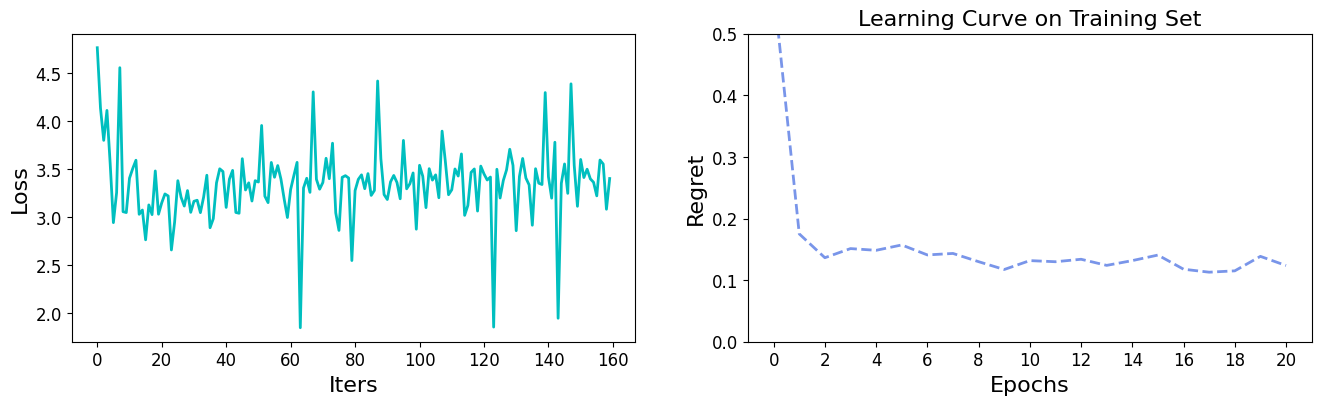

In [51]:
# init ltr loss
ltr = pyepo.func.lsLTR(optmodel, processes=1, solve_ratio=0.10, dataset=dataset_train)
# train
trainModel(reg, loss_func=ltr, method_name="ltr")

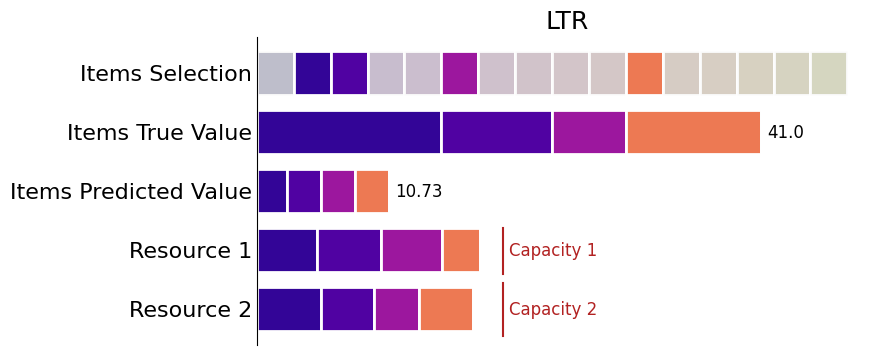

In [52]:
# compare solutions
visSol(loader_test, optmodel, ind, pytorch_model=reg, method_name="LTR")

## Summary

- A visual tour of predict-then-optimize on the 2D knapsack: for each method, the predicted item values, the items it selects, and how that selection fills the two resource capacities are drawn side by side against the true optimum.
- Comparing SPO+, PG, PFYL, DPO, I-MLE, RFWO / RFYL, DBB, NID, NCE, and LTR on the same instance shows how decision-focused training recovers good decisions even when the predicted values are imperfect.
- **Next:** see how these losses are trained in [03 Training and Testing](https://github.com/khalil-research/PyEPO/blob/main/notebooks/03%20Training%20and%20Testing.ipynb), or pick a method in the [documentation](https://khalil-research.github.io/PyEPO/build/html/content/examples/function.html#choosing-a-method).